# 노트북 §7 실험 B 재현 — centering의 효과는 어떻게 측정됐는가

**질문**: 노트북 §7 실험 B에서 centering의 효과는 어떻게 측정됐는가?

**답**: "프로토타입 0에 bias 2.0을 준 상황에서 argmax가 0이 되는 비율"을 관측했다.
centering 없음 = **0.819** (한 프로토타입이 독식), centering 있음 = **0.003** 으로
uniform 기대값 $1/K = 1/512 = 0.0020$ 에 근접했다.

## 측정 설계

$K$개 프로토타입 로짓을 매 step 새로 뽑되, 0번 성분에만 구조적 이득(bias)을 준다.

$$ z_t \sim 0.5\cdot\mathcal{N}(0, I_K) + b,\qquad b_0 = 2.0,\; b_{k\neq 0}=0 $$

centering은 EMA로 누적한 배치 평균 $c$ 를 로짓에서 빼는 것뿐이다
(DINO 원본 `DINOLoss.update_center` 와 동일 형태 — softmax 이전의 raw 출력 평균).

$$ c \leftarrow m_c\, c + (1-m_c)\,\frac{1}{B}\sum_{i=1}^{B} z_t^{(i)},\qquad
   P_t = \mathrm{softmax}\!\big((z_t - c)/\tau_t\big) $$

**관측량(metric)** 은 두 개다.

$$ \text{독식비율} = \frac{1}{B}\sum_i \mathbb{1}\big[\arg\max_k P_t^{(i)} = 0\big],
   \qquad H(P_t) = -\sum_k P_t\log P_t $$

핵심은 이 대비다: centering은 **독식비율만** 바꾸고 **엔트로피는 거의 안 바꾼다**.
즉 centering은 "어떤 프로토타입이 뽑히나", sharpening($\tau_t$)은 "얼마나 확신하나"를 담당한다.

In [1]:
# 필요 패키지: torch(2.4), numpy, plotly(6.9), kaleido
import os
import math
import torch
import numpy as np
import torch.nn.functional as F
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:  # VSCode 셀/Jupyter에서만 렌더링
            fig.show()
    except ImportError:
        pass


HERE = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

# 노트북 §7과 동일한 하이퍼파라미터/시드
K, Bsz, STEPS = 512, 64, 300
TAU_T = 0.04
bias = torch.zeros(K)
bias[0] = 2.0        # 프로토타입 0 이 구조적으로 유리한 상황

print(f"K={K}, B={Bsz}, steps={STEPS}, tau_t={TAU_T}, bias[0]={bias[0].item()}")
print(f"uniform 기대값 1/K = {1/K:.4f}")

K=512, B=64, steps=300, tau_t=0.04, bias[0]=2.0
uniform 기대값 1/K = 0.0020


## 1. 실험 B 시뮬레이터 (노트북과 동일)

`use_center=False` 면 raw 로짓, `True` 면 $z_t - c$ 를 softmax에 넣는다.
center는 **매 step 갱신되지만 그 step의 관측은 갱신 이전 값으로** 한다 (원본 루프와 동일).

In [2]:
def simulate(use_center, tau_t=TAU_T, m_c=0.9, steps=STEPS, seed=1, b0=2.0):
    gg = torch.Generator().manual_seed(seed)
    bb = torch.zeros(K); bb[0] = b0
    center = torch.zeros(1, K)
    hist_dom, hist_ent, hist_c0 = [], [], []
    for _ in range(steps):
        zt = torch.randn(Bsz, K, generator=gg) * 0.5 + bb
        logits = zt - center if use_center else zt
        p = F.softmax(logits / tau_t, dim=-1)
        hist_dom.append((p.argmax(-1) == 0).float().mean().item())
        hist_ent.append((-(p * p.clamp_min(1e-12).log()).sum(-1)).mean().item())
        hist_c0.append(center[0, 0].item())
        center = m_c * center + (1 - m_c) * zt.mean(0, keepdim=True)   # EMA
    return np.array(hist_dom), np.array(hist_ent), np.array(hist_c0), center


dom_on, ent_on, c0_on, c_on = simulate(True)
dom_off, ent_off, c0_off, _ = simulate(False)

print(f"centering 없음: 프로토타입 0 독식 비율 {dom_off[-50:].mean():.3f}")
print(f"centering 있음: 프로토타입 0 독식 비율 {dom_on[-50:].mean():.3f}"
      f"   (uniform 기대값 {1/K:.4f})")

centering 없음: 프로토타입 0 독식 비율 0.819
centering 있음: 프로토타입 0 독식 비율 0.003   (uniform 기대값 0.0020)


## 2. center가 bias를 흡수했는가

EMA center의 0번 성분은 주입한 bias 2.0으로 수렴해야 한다.
수렴 속도는 기하급수적이다: $c_0(t) \approx 2.0\,(1 - m_c^{\,t})$, 즉 $m_c=0.9$ 면 $\sim$20 step.

In [3]:
print(f"학습된 c[0]      = {c_on[0, 0]:.3f}   (주입한 bias = 2.0)")
print(f"나머지 성분 평균 = {c_on[0, 1:].mean():.3f}  (bias 없음 -> 0 근처)")
for t in [0, 5, 10, 20, 50, 100, 299]:
    print(f"  step {t:3d}: c0={c0_on[t]:.4f}   이론 2.0*(1-0.9^t)={2.0*(1-0.9**t):.4f}")

학습된 c[0]      = 2.011   (주입한 bias = 2.0)
나머지 성분 평균 = -0.000  (bias 없음 -> 0 근처)
  step   0: c0=0.0000   이론 2.0*(1-0.9^t)=0.0000
  step   5: c0=0.8211   이론 2.0*(1-0.9^t)=0.8190
  step  10: c0=1.2990   이론 2.0*(1-0.9^t)=1.3026
  step  20: c0=1.7615   이론 2.0*(1-0.9^t)=1.7568
  step  50: c0=2.0121   이론 2.0*(1-0.9^t)=1.9897
  step 100: c0=1.9819   이론 2.0*(1-0.9^t)=1.9999
  step 299: c0=2.0101   이론 2.0*(1-0.9^t)=2.0000


## 3. 엔트로피는 거의 안 변한다 (핵심 대비)

독식비율은 0.819 → 0.003 으로 **291배** 줄었는데, $H(P_t)$ 는 둘 다
$\log K = 6.238$ 의 10% 미만에 머문다 — 즉 교사 분포는 여전히 sharp하다.
centering은 붕괴의 "방향"만 고치지 sharpening($\tau_t$)을 대체하지 못한다.

In [4]:
print(f"H(P_t) centering 없음 = {ent_off[-50:].mean():.4f} nats")
print(f"H(P_t) centering 있음 = {ent_on[-50:].mean():.4f} nats")
print(f"차이 = {abs(ent_on[-50:].mean() - ent_off[-50:].mean()):.4f} nats  "
      f"-> log K = {math.log(K):.3f} 대비 "
      f"{abs(ent_on[-50:].mean() - ent_off[-50:].mean())/math.log(K)*100:.1f}%")
print(f"독식비율 배율 변화 = {dom_off[-50:].mean() / max(dom_on[-50:].mean(), 1e-9):.0f}배")

H(P_t) centering 없음 = 0.1281 nats
H(P_t) centering 있음 = 0.4769 nats
차이 = 0.3487 nats  -> log K = 6.238 대비 5.6%
독식비율 배율 변화 = 291배


## 4. bias 크기 × center momentum $m_c$ 표

bias가 커질수록 centering 없이는 완전 독식(1.000)으로 가지만,
center가 있으면 bias 크기와 무관하게 uniform 기대값 근처로 돌아온다.
$m_c=0.99$ 는 흡수가 느려(시정수 $\sim$100 step) 300 step 창에서는 초반 잔여 독식이 남는다.

In [5]:
print(f"{'bias':>5} | {'no-center':>9} | {'m_c=0.9':>9} | {'m_c=0.99':>9} | {'uniform':>8}")
print("-" * 54)
for b0 in [0.5, 1.0, 2.0, 4.0]:
    d_off = simulate(False, b0=b0)[0][-50:].mean()
    d_09 = simulate(True, m_c=0.9, b0=b0)[0][-50:].mean()
    d_099 = simulate(True, m_c=0.99, b0=b0)[0][-50:].mean()
    print(f"{b0:5.1f} | {d_off:9.3f} | {d_09:9.3f} | {d_099:9.3f} | {1/K:8.4f}")

 bias | no-center |   m_c=0.9 |  m_c=0.99 |  uniform
------------------------------------------------------
  0.5 |     0.028 |     0.003 |     0.004 |   0.0020
  1.0 |     0.167 |     0.003 |     0.005 |   0.0020
  2.0 |     0.819 |     0.003 |     0.007 |   0.0020
  4.0 |     1.000 |     0.003 |     0.010 |   0.0020


## 5. 시각화

- 왼쪽: 마지막 50 step 동안 argmax가 어느 프로토타입을 골랐는지 히스토그램 (centering 전/후)
- 가운데: 독식비율 궤적 — 점선이 uniform 기대값 $1/K$
- 오른쪽: $c_0$ 가 2.0으로 수렴하는 궤적 ($m_c$ = 0.9 vs 0.99)

[no-center] proto0 선택 2622/3200, 서로 다른 프로토타입 수 349
[center]    proto0 선택 9/3200, 서로 다른 프로토타입 수 512


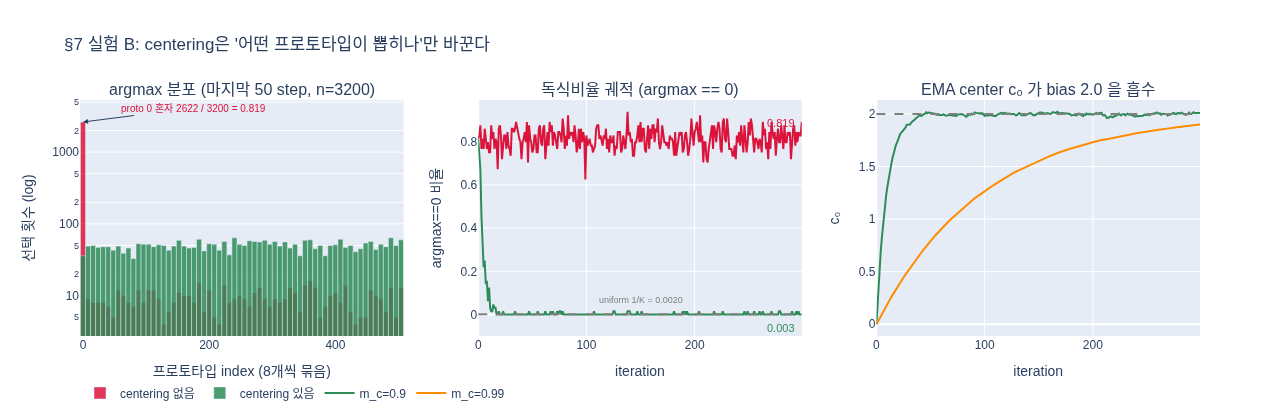

saved: /home/sungwoo/projects/swcho/dino/fm/training/.fm/hints/d3f7da30-b26d-450f-8682-bc4cf64a03d3/expy.png


In [6]:
def argmax_counts(use_center, m_c=0.9, tail=50):
    gg = torch.Generator().manual_seed(1)
    center = torch.zeros(1, K)
    acc = []
    for t in range(STEPS):
        zt = torch.randn(Bsz, K, generator=gg) * 0.5 + bias
        logits = zt - center if use_center else zt
        p = F.softmax(logits / TAU_T, dim=-1)
        if t >= STEPS - tail:
            acc.append(p.argmax(-1))
        center = m_c * center + (1 - m_c) * zt.mean(0, keepdim=True)
    return torch.cat(acc).numpy()


am_off, am_on = argmax_counts(False), argmax_counts(True)
c0_099 = simulate(True, m_c=0.99)[2]

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=(
        "argmax 분포 (마지막 50 step, n=3200)",
        "독식비율 궤적 (argmax == 0)",
        "EMA center c₀ 가 bias 2.0 을 흡수",
    ),
)
cnt_off = np.bincount(am_off, minlength=K)
cnt_on = np.bincount(am_on, minlength=K)
# 512개를 8개씩 64묶음으로 합쳐 막대를 읽을 수 있게 한다 (0번은 첫 묶음에 들어간다)
GRP = 8
grp_off = cnt_off.reshape(-1, GRP).sum(1)
grp_on = cnt_on.reshape(-1, GRP).sum(1)
gx = np.arange(0, K, GRP)
fig.add_trace(go.Bar(x=gx, y=grp_off, name="centering 없음", width=GRP,
                     marker_color="crimson", opacity=0.85), row=1, col=1)
fig.add_trace(go.Bar(x=gx, y=grp_on, name="centering 있음", width=GRP,
                     marker_color="seagreen", opacity=0.85), row=1, col=1)
fig.add_annotation(x=0, y=math.log10(max(grp_off[0], 1)), xref="x", yref="y",
                   text=f"proto 0 혼자 {cnt_off[0]} / {len(am_off)} = "
                        f"{cnt_off[0]/len(am_off):.3f}",
                   showarrow=True, arrowhead=2, ax=110, ay=-14,
                   font=dict(size=10, color="crimson"), row=1, col=1)

print(f"[no-center] proto0 선택 {cnt_off[0]}/{len(am_off)}, "
      f"서로 다른 프로토타입 수 {int((cnt_off > 0).sum())}")
print(f"[center]    proto0 선택 {cnt_on[0]}/{len(am_on)}, "
      f"서로 다른 프로토타입 수 {int((cnt_on > 0).sum())}")
fig.add_trace(go.Scatter(y=dom_off, name="centering 없음", line=dict(color="crimson"),
                         showlegend=False), row=1, col=2)
fig.add_trace(go.Scatter(y=dom_on, name="centering 있음", line=dict(color="seagreen"),
                         showlegend=False), row=1, col=2)
fig.add_hline(y=1 / K, line=dict(color="gray", dash="dash"), row=1, col=2)
fig.add_annotation(x=150, y=1 / K, text="uniform 1/K = 0.0020", showarrow=False,
                   yshift=14, font=dict(size=9, color="gray"), row=1, col=2)
fig.add_annotation(x=280, y=dom_off[-50:].mean(), text=f"{dom_off[-50:].mean():.3f}",
                   showarrow=False, yshift=14, font=dict(size=11, color="crimson"),
                   row=1, col=2)
fig.add_annotation(x=280, y=dom_on[-50:].mean(), text=f"{dom_on[-50:].mean():.3f}",
                   showarrow=False, yshift=-14, font=dict(size=11, color="seagreen"),
                   row=1, col=2)
fig.add_trace(go.Scatter(y=c0_on, name="m_c=0.9", line=dict(color="seagreen")), row=1, col=3)
fig.add_trace(go.Scatter(y=c0_099, name="m_c=0.99", line=dict(color="darkorange")), row=1, col=3)
fig.add_hline(y=2.0, line=dict(color="gray", dash="dash"), row=1, col=3)

fig.update_xaxes(title_text="프로토타입 index (8개씩 묶음)", row=1, col=1)
fig.update_yaxes(title_text="선택 횟수 (log)", type="log", row=1, col=1)
fig.update_xaxes(title_text="iteration", row=1, col=2)
fig.update_yaxes(title_text="argmax==0 비율", row=1, col=2)
fig.update_xaxes(title_text="iteration", row=1, col=3)
fig.update_yaxes(title_text="c₀", row=1, col=3)
fig.update_layout(barmode="overlay", height=420, width=1280,
                  title_text="§7 실험 B: centering은 '어떤 프로토타입이 뽑히나'만 바꾼다",
                  legend=dict(orientation="h", y=-0.18))

_show(fig)
fig.write_image(os.path.join(HERE, "expy.png"), scale=2)
print("saved:", os.path.join(HERE, "expy.png"))

## 정리

| | centering 없음 | centering 있음 | uniform 기대 |
|---|---|---|---|
| argmax==0 비율 | **0.819** | **0.003** | 0.0020 |
| $H(P_t)$ [nats] | 0.128 | 0.477 | $\log K = 6.238$ |

- **측정 방법** = "프로토타입 0에 bias 2.0을 준 뒤, 배치에서 argmax가 0이 되는 비율"을
  300 step 돌려 마지막 50 step 평균으로 읽는다.
- centering은 EMA center가 그 bias(→ $c_0 \to 2.011$)를 흡수해 빼주므로 argmax가 흩어진다.
- 독식비율은 **291배** 달라졌는데 엔트로피는 둘 다 $\log K$ 의 10% 미만에 머문다
  (0.128 → 0.477). centering은 uniform collapse를 막는 장치가 아니라
  **단일 프로토타입 collapse**를 막는 장치이고, 그래서 sharpening과 짝을 이뤄야 한다.